# AI-Powered Resume Screener
**Goal:** Classify resumes into job categories using NLP + Machine Learning

**Pipeline:**
1. Load & Explore Data (EDA)
2. Text Preprocessing & Cleaning
3. Feature Engineering (TF-IDF)
4. Model Training & Benchmarking
5. Evaluation & Insights
6. Save Model for Deployment

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load & Explore Data (EDA)

In [2]:
df = pd.read_csv('Resume.csv')
print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Dataset Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# Basic info
print('Total Resumes:', len(df))
print('Total Categories:', df['Category'].nunique())
print('\nMissing Values:')
print(df.isnull().sum())

Total Resumes: 2484
Total Categories: 24

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


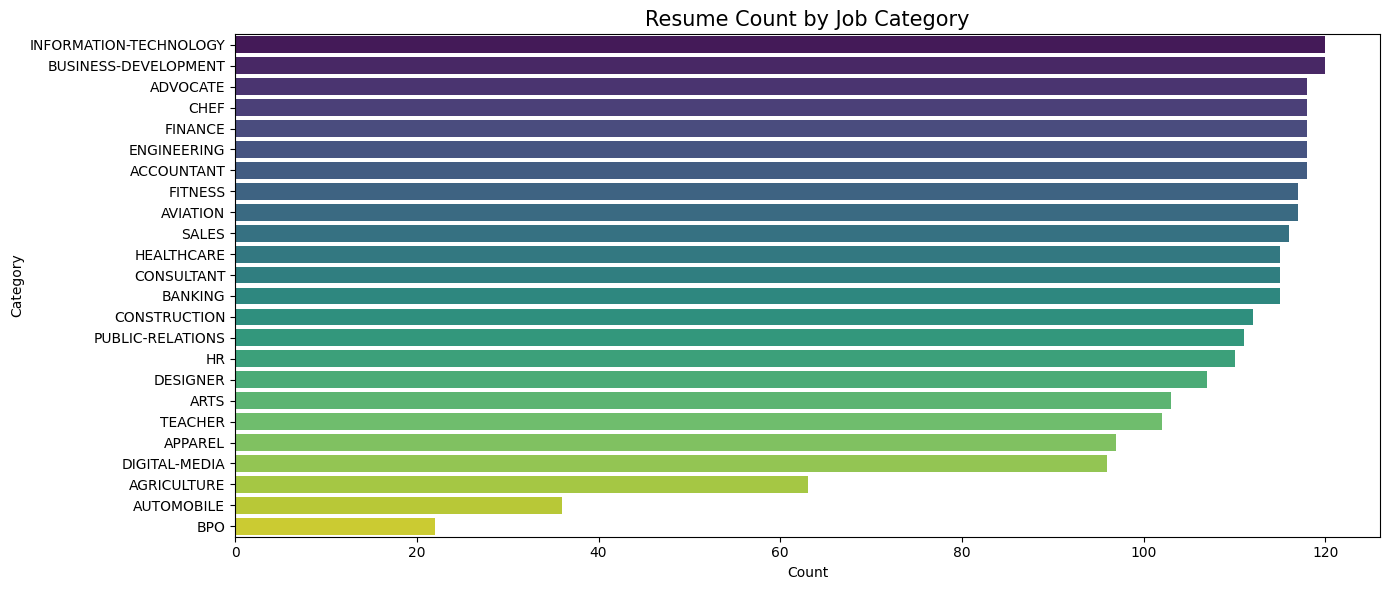


Category Distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [4]:
# Category Distribution
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Resume Count by Job Category', fontsize=15)
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()
print('\nCategory Distribution:')
print(category_counts)

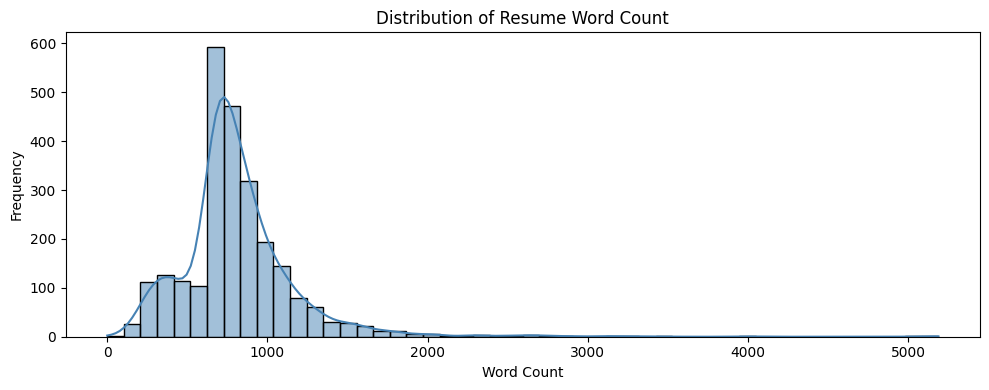

Average resume length: 811 words
Min: 0 | Max: 5190


In [5]:
# Resume length analysis
df['resume_length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['resume_length'], bins=50, color='steelblue', kde=True)
plt.title('Distribution of Resume Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Average resume length: {df["resume_length"].mean():.0f} words')
print(f'Min: {df["resume_length"].min()} | Max: {df["resume_length"].max()}')

## 3. Text Preprocessing

In [6]:
def clean_resume(text):
    """
    Clean raw resume text:
    - Remove URLs, emails, special characters
    - Lowercase
    - Remove extra whitespace
    """
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

# Show before/after
print('BEFORE CLEANING:')
print(df['Resume_str'].iloc[0][:300])
print('\nAFTER CLEANING:')
print(df['cleaned_resume'].iloc[0][:300])

BEFORE CLEANING:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

AFTER CLEANING:
hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service highli


## 4. Feature Engineering & Train-Test Split

In [7]:
# Encode target labels
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

print('Categories encoded:')
for i, cat in enumerate(le.classes_):
    print(f'  {i}: {cat}')

Categories encoded:
  0: ACCOUNTANT
  1: ADVOCATE
  2: AGRICULTURE
  3: APPAREL
  4: ARTS
  5: AUTOMOBILE
  6: AVIATION
  7: BANKING
  8: BPO
  9: BUSINESS-DEVELOPMENT
  10: CHEF
  11: CONSTRUCTION
  12: CONSULTANT
  13: DESIGNER
  14: DIGITAL-MEDIA
  15: ENGINEERING
  16: FINANCE
  17: FITNESS
  18: HEALTHCARE
  19: HR
  20: INFORMATION-TECHNOLOGY
  21: PUBLIC-RELATIONS
  22: SALES
  23: TEACHER


In [8]:
X = df['cleaned_resume']
y = df['Category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 1987
Testing samples:  497


## 5. Model Training & Benchmarking
We compare 3 models and pick the best one.

In [9]:
# Define models to benchmark
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Linear SVC': LinearSVC(max_iter=1000, random_state=42)
}

results = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = {'pipeline': pipeline, 'accuracy': acc, 'predictions': y_pred}
    print(f'{model_name}: Accuracy = {acc:.4f} ({acc*100:.2f}%)')

Logistic Regression: Accuracy = 0.6419 (64.19%)
Random Forest: Accuracy = 0.7103 (71.03%)
Linear SVC: Accuracy = 0.7062 (70.62%)


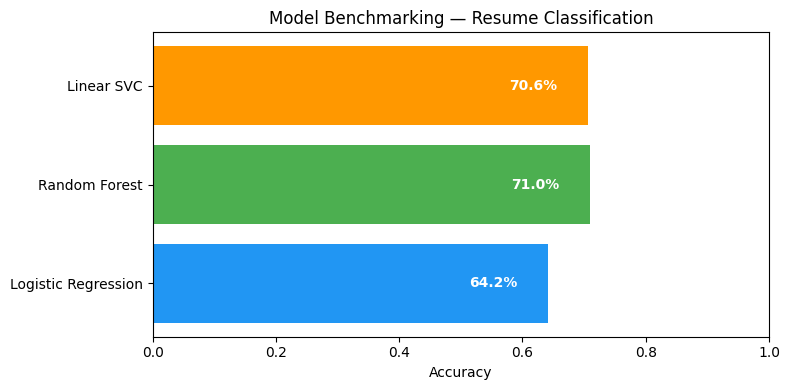

In [10]:
# Model comparison chart
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

plt.figure(figsize=(8, 4))
bars = plt.barh(model_names, accuracies, color=['#2196F3', '#4CAF50', '#FF9800'])
plt.xlabel('Accuracy')
plt.title('Model Benchmarking — Resume Classification')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.1f}%', va='center', ha='right', color='white', fontweight='bold')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 6. Best Model — Detailed Evaluation

In [11]:
# Pick best model
best_model_name = max(results, key=lambda m: results[m]['accuracy'])
best_pipeline = results[best_model_name]['pipeline']
best_preds = results[best_model_name]['predictions']

print(f'Best Model: {best_model_name}')
print(f'Accuracy: {results[best_model_name]["accuracy"]*100:.2f}%')
print('\nDetailed Classification Report:')
print(classification_report(y_test, best_preds, target_names=le.classes_))

Best Model: Random Forest
Accuracy: 71.03%

Detailed Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.92      0.76        24
              ADVOCATE       0.82      0.75      0.78        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       0.70      0.37      0.48        19
                  ARTS       0.29      0.10      0.14        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.81      0.88      0.84        24
               BANKING       0.86      0.52      0.65        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.69      0.92      0.79        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.91      0.91      0.91        22
            CONSULTANT       0.64      0.39      0.49        23
              DESIGNER     

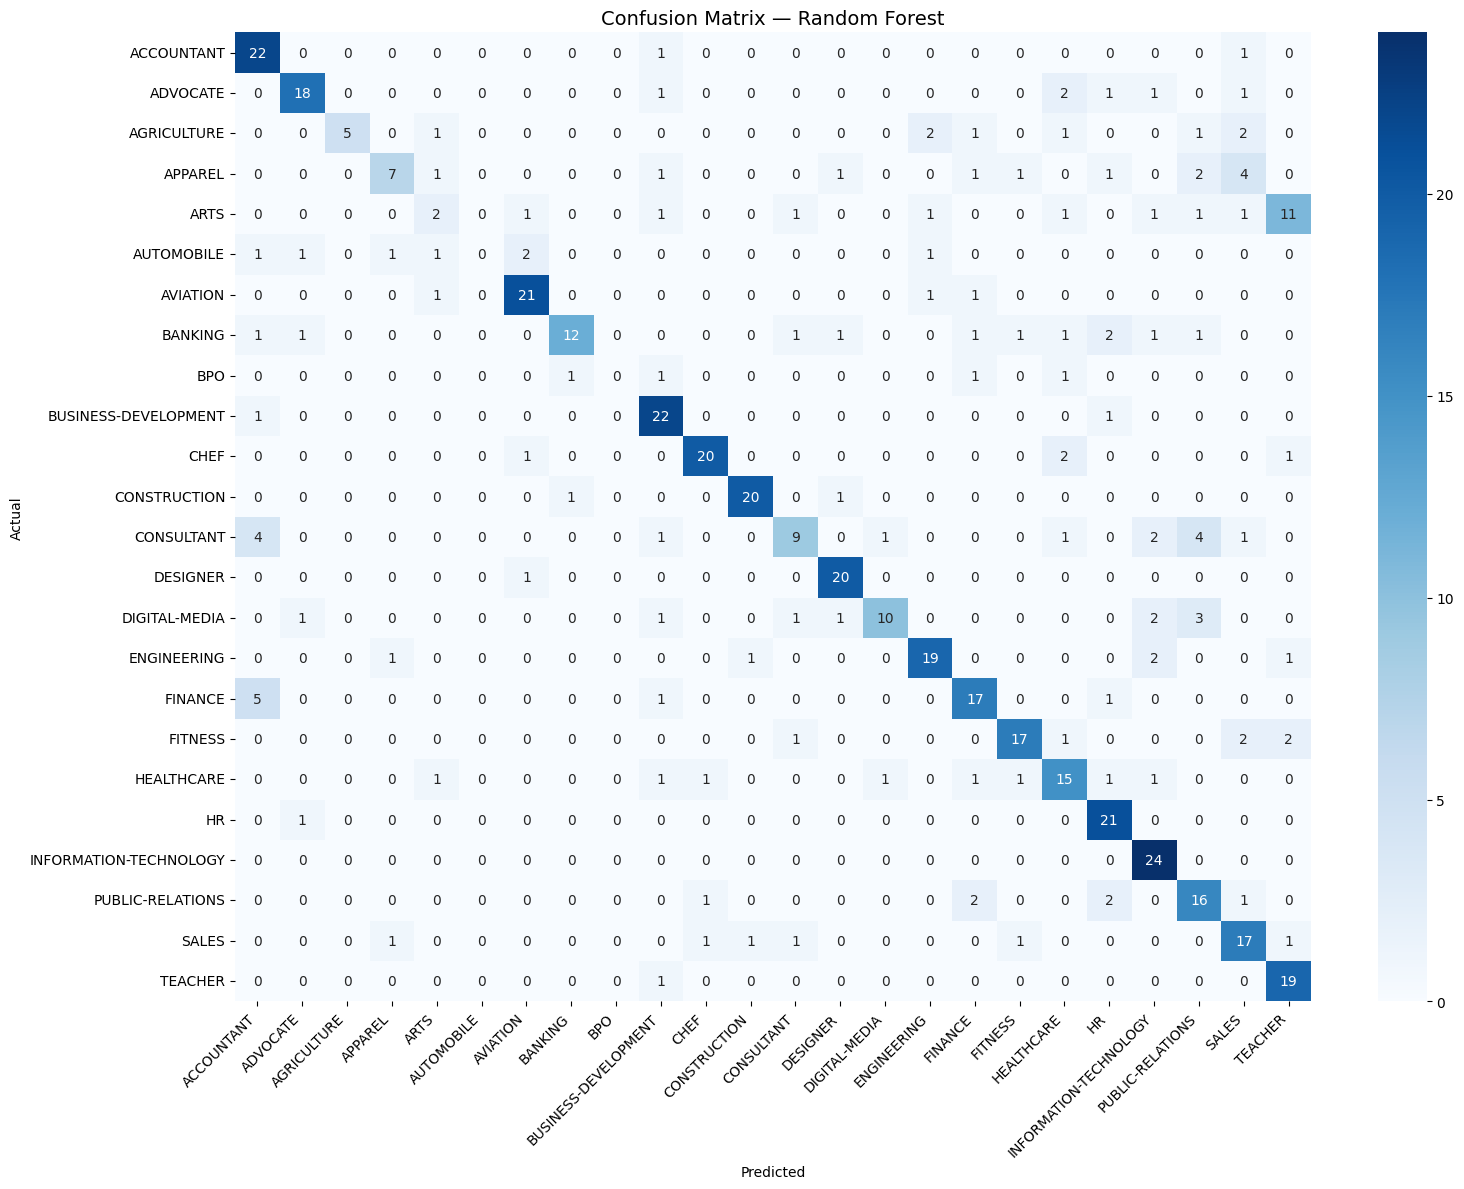

In [12]:
# Confusion Matrix (Top 10 categories for readability)
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 7. Inference — Predict on New Resume

In [13]:
def predict_resume_category(resume_text, pipeline, label_encoder):
    """
    Takes raw resume text and returns predicted job category with confidence score.
    """
    cleaned = clean_resume(resume_text)
    prediction = pipeline.predict([cleaned])[0]
    category = label_encoder.inverse_transform([prediction])[0]
    
    # Get confidence if model supports it
    try:
        proba = pipeline.predict_proba([cleaned])[0]
        confidence = round(max(proba) * 100, 2)
    except:
        confidence = 'N/A (model does not support probability)'
    
    return {'predicted_category': category, 'confidence': confidence}


# Test with a sample resume
sample_resume = """
Experienced Data Scientist with 3 years in machine learning and analytics.
Proficient in Python, Scikit-learn, TensorFlow, SQL, and data visualization.
Built predictive models for customer churn and fraud detection.
Strong background in statistical analysis, A/B testing, and feature engineering.
"""

result = predict_resume_category(sample_resume, best_pipeline, le)
print('Sample Resume Prediction:')
print(f"  Predicted Category : {result['predicted_category']}")
print(f"  Confidence         : {result['confidence']}%")

Sample Resume Prediction:
  Predicted Category : ENGINEERING
  Confidence         : 32.0%


## 8. Save Model

In [14]:
# Save pipeline and label encoder
joblib.dump(best_pipeline, 'resume_screener_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print('Model saved: resume_screener_model.pkl')
print('Label encoder saved: label_encoder.pkl')
print('\nTo load and use:')
print("  pipeline = joblib.load('resume_screener_model.pkl')")
print("  le = joblib.load('label_encoder.pkl')")

Model saved: resume_screener_model.pkl
Label encoder saved: label_encoder.pkl

To load and use:
  pipeline = joblib.load('resume_screener_model.pkl')
  le = joblib.load('label_encoder.pkl')


## 9. Key Insights & Summary

In [15]:
print('=' * 55)
print('        RESUME SCREENER — PROJECT SUMMARY')
print('=' * 55)
print(f'Dataset        : 2,484 resumes across 24 job categories')
print(f'Best Model     : {best_model_name}')
print(f'Accuracy       : {results[best_model_name]["accuracy"]*100:.2f}%')
print(f'Features       : TF-IDF (5000 features, bigrams)')
print(f'Pipeline       : clean → vectorize → classify → score')
print('=' * 55)
print('Models Benchmarked:')
for name, res in results.items():
    marker = '✓ BEST' if name == best_model_name else ''
    print(f'  {name:<25} {res["accuracy"]*100:.2f}%  {marker}')
print('=' * 55)

        RESUME SCREENER — PROJECT SUMMARY
Dataset        : 2,484 resumes across 24 job categories
Best Model     : Random Forest
Accuracy       : 71.03%
Features       : TF-IDF (5000 features, bigrams)
Pipeline       : clean → vectorize → classify → score
Models Benchmarked:
  Logistic Regression       64.19%  
  Random Forest             71.03%  ✓ BEST
  Linear SVC                70.62%  
